# SemRel — Model Evaluation & Comparison
**COS 760 Group Project**  
Loads predictions from all models and produces a unified comparison across:
- **AfriBERT** (XLM-RoBERTa-base fine-tuned, notebook 04)
- **Embedding cosine baseline** (multilingual sentence-transformer, from notebook 03)
- **TF-IDF cosine baseline** (from notebook 03)

Metrics: Spearman ρ, Pearson r, MSE, RMSE — on the **test** split.

## 1. Install & Import Dependencies

In [1]:
!pip install pandas numpy matplotlib seaborn scipy scikit-learn -q

In [2]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_squared_error

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size']  = 11

DATA_DIR       = './cleaned_data'
AFRIBERTA_DIR  = './model_outputs/afriberta'   # Wadalisa
SBERT_DIR      = './model_outputs/sbert'        # Lesedi
XLMR_DIR       = './model_outputs/xlmr'         # Meinka
OUTPUT_DIR     = './evaluation_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


## 2. Load Gold Labels & Model Predictions

In [3]:
# ── Gold labels ───────────────────────────────────────────────────────────────
test_df = pd.read_csv(os.path.join(DATA_DIR, 'afr_test.csv'))
gold    = test_df['score'].values
print(f'Test set: {len(test_df)} pairs')
display(test_df.head(3))

# ── AfriBERTa predictions (Wadalisa) ──────────────────────────────────────────
afriberta_path = os.path.join(AFRIBERTA_DIR, 'test_predictions.csv')
if os.path.exists(afriberta_path):
    afriberta_df    = pd.read_csv(afriberta_path)
    afriberta_preds = afriberta_df['afriberta_pred'].values
    print(f'AfriBERTa predictions loaded: {len(afriberta_preds)} rows')
else:
    print(f'WARNING: {afriberta_path} not found — run 04_AfriBERT.ipynb first.')
    afriberta_preds = None

# ── SBERT predictions (Lesedi) ──────────────────────────────────────────────
sbert_path = os.path.join(SBERT_DIR, 'test_predictions.csv')
if os.path.exists(sbert_path):
    sbert_df    = pd.read_csv(sbert_path)
    sbert_preds = sbert_df['sbert_pred'].values
    print(f'SBERT predictions loaded: {len(sbert_preds)} rows')
else:
    print(f'WARNING: {sbert_path} not found — run 04_SBERT_NEW.ipynb first.')
    sbert_preds = None

# ── XLM-R predictions (Meinka) ──────────────────────────────────────────────
xlmr_path = os.path.join(XLMR_DIR, 'test_predictions.csv')
if os.path.exists(xlmr_path):
    xlmr_df    = pd.read_csv(xlmr_path)
    xlmr_preds = xlmr_df['xlmr_pred'].values
    print(f'XLM-R predictions loaded: {len(xlmr_preds)} rows')
else:
    print(f'WARNING: {xlmr_path} not found — run 04_XLM-R.ipynb first.')
    xlmr_preds = None

Test set: 375 pairs


,sentence1,sentence2,score,lang,split
0,Venus beweeg tot 16 November agteruit deur jou...,"Venus, die plesierplaneet, beweeg die volgende...",0.75,afr,test
1,Ons leer immers ons kinders n rein liggaam is ...,Net so is n skoon omgewing die naaste aan n sk...,0.69,afr,test
2,Ek verstaan hoekom ons Hemelse Vader n vrou ge...,Ek verstaan ook hoe n man sy vrou moet lief he...,0.66,afr,test


AfriBERTa predictions loaded: 375 rows


## 3. Metric Helper

In [4]:
def compute_metrics(preds: np.ndarray, gold: np.ndarray, name: str) -> dict:
    """Return a dict of evaluation metrics for one model."""
    mse      = float(np.mean((preds - gold) ** 2))
    rmse     = float(np.sqrt(mse))
    pearson  = float(pearsonr(preds, gold)[0])
    spearman = float(spearmanr(preds, gold)[0])
    return {
        'Model':    name,
        'Spearman': round(spearman, 4),
        'Pearson':  round(pearson, 4),
        'MSE':      round(mse, 4),
        'RMSE':     round(rmse, 4),
    }


## 4. Compute All Metrics

In [5]:
results = []

if sbert_preds is not None:
    results.append(compute_metrics(sbert_preds, gold, 'SBERT'))

if xlmr_preds is not None:
    results.append(compute_metrics(xlmr_preds, gold, 'XLM-RoBERTa (fine-tuned)'))

if afriberta_preds is not None:
    results.append(compute_metrics(afriberta_preds, gold, 'AfriBERTa (fine-tuned)'))

results_df = pd.DataFrame(results).set_index('Model')

print('Test-set results:')
display(results_df.style.highlight_max(axis=0, subset=['Spearman', 'Pearson'], color='#b7e4c7')
                        .highlight_min(axis=0, subset=['MSE', 'RMSE'], color='#b7e4c7')
                        .format('{:.4f}'))


Test-set results:


,Spearman,Pearson,MSE,RMSE
Model,,,,
AfriBERTa (fine-tuned),0.1527,0.1593,0.0534,0.2311


## 5. Bar Charts — Metric Comparison

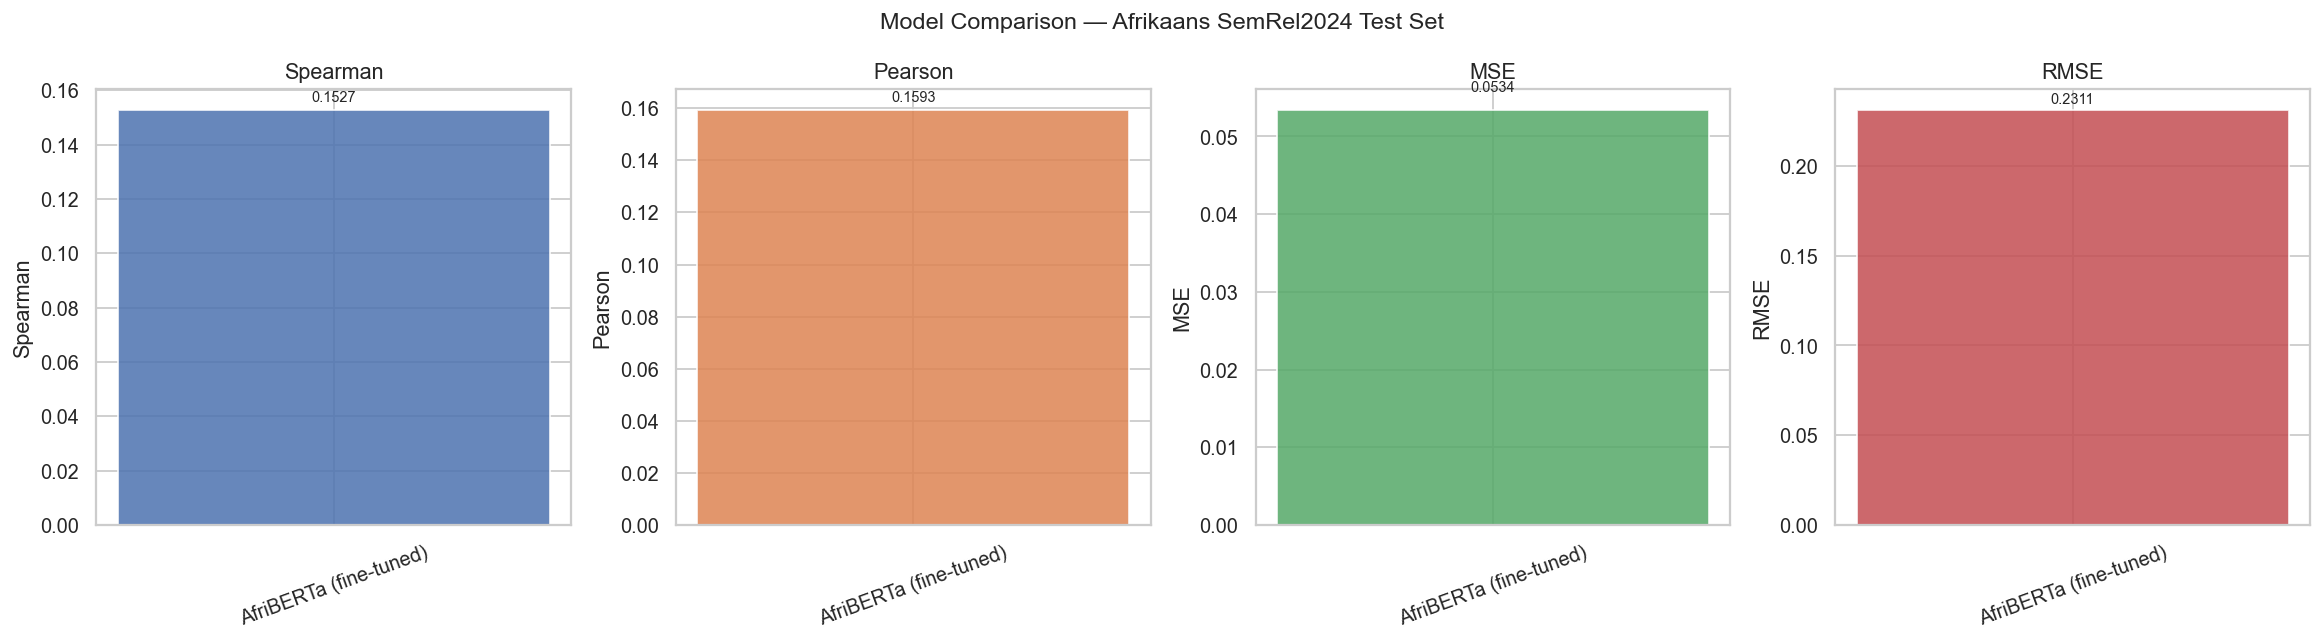

In [6]:
if results:
    models = [r['Model'] for r in results]
    metrics = ['Spearman', 'Pearson', 'MSE', 'RMSE']
    colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    for ax, metric, color in zip(axes, metrics, colors):
        vals = [r[metric] for r in results]
        bars = ax.bar(models, vals, color=color, edgecolor='white', alpha=0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.002,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=8)
        ax.set_title(metric)
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=20)

    fig.suptitle('Model Comparison — Afrikaans SemRel2024 Test Set', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'metric_comparison_bars.png'), dpi=150, bbox_inches='tight')
    plt.show()


## 6. Scatter Plots — Predicted vs Gold

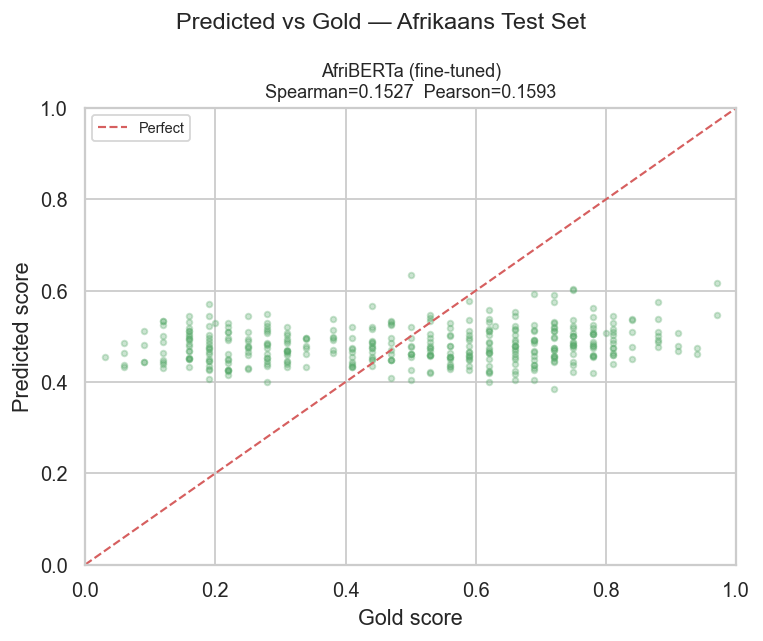

In [7]:
models_to_plot = []
if sbert_preds is not None:
    models_to_plot.append(('SBERT', sbert_preds, '#4C72B0'))
if xlmr_preds is not None:
    models_to_plot.append(('XLM-RoBERTa (fine-tuned)', xlmr_preds, '#DD8452'))
if afriberta_preds is not None:
    models_to_plot.append(('AfriBERTa (fine-tuned)', afriberta_preds, '#55A868'))

n = len(models_to_plot)
if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1: axes = [axes]

    for ax, (name, preds, color) in zip(axes, models_to_plot):
        ax.scatter(gold, preds, alpha=0.3, s=10, color=color)
        ax.plot([0, 1], [0, 1], 'r--', linewidth=1.2, label='Perfect')
        spear = spearmanr(preds, gold)[0]
        pear  = pearsonr(preds, gold)[0]
        ax.set_title(f'{name}\nSpearman={spear:.4f}  Pearson={pear:.4f}', fontsize=10)
        ax.set_xlabel('Gold score')
        ax.set_ylabel('Predicted score')
        ax.legend(fontsize=8)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    fig.suptitle('Predicted vs Gold — Afrikaans Test Set', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'scatter_all_models.png'), dpi=150, bbox_inches='tight')
    plt.show()


## 7. Residual Analysis

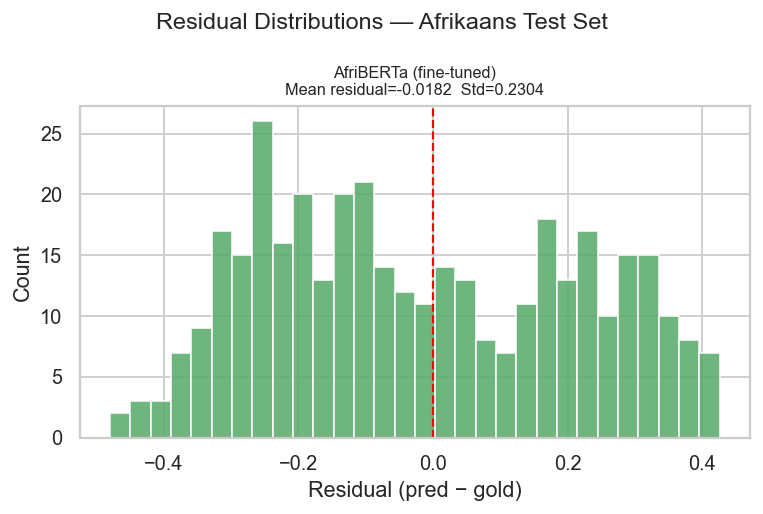

In [8]:
if models_to_plot:
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1: axes = [axes]

    for ax, (name, preds, color) in zip(axes, models_to_plot):
        residuals = preds - gold
        ax.hist(residuals, bins=30, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(0, color='red', linestyle='--', linewidth=1.2)
        ax.set_title(f'{name}\nMean residual={residuals.mean():.4f}  Std={residuals.std():.4f}', fontsize=9)
        ax.set_xlabel('Residual (pred − gold)')
        ax.set_ylabel('Count')

    fig.suptitle('Residual Distributions — Afrikaans Test Set', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'residuals_all_models.png'), dpi=150, bbox_inches='tight')
    plt.show()


## 8. Error Analysis — Worst Predictions
Inspect pairs where the best model is furthest from the gold label.

In [9]:
if afriberta_preds is not None:
    error_df = test_df[['sentence1', 'sentence2', 'score']].copy()
    error_df.rename(columns={'score': 'gold'}, inplace=True)
    error_df['afriberta_pred'] = afriberta_preds
    error_df['abs_error']      = (error_df['afriberta_pred'] - error_df['gold']).abs()
    error_df = error_df.sort_values('abs_error', ascending=False)

    print('Top 10 worst predictions (AfriBERTa):')
    display(error_df.head(10)[['sentence1', 'sentence2', 'gold', 'afriberta_pred', 'abs_error']])

    error_df.to_csv(os.path.join(OUTPUT_DIR, 'error_analysis.csv'), index=False)
    print(f'\nFull error analysis saved to {OUTPUT_DIR}/error_analysis.csv')
else:
    print('AfriBERTa predictions not available for error analysis.')

Top 10 worst predictions (AfriBERTa):


,sentence1,sentence2,gold,afriberta_pred,abs_error
100,Hondsdolheid is n potensieel dodelike siekte w...,Neem dan die persoon na n hospitaal sodat n en...,0.94,0.460257,0.479743
258,Newton se gevolgtrekking was dat n reënboog op...,In sekere omstandighede word n dubbele reënboo...,0.94,0.475174,0.464826
214,Dalk is dit maar net hoe n mens voel wanneer j...,Ek is so opgepof soos net n eerste keer ouma k...,0.91,0.468146,0.441854
235,"Omdat lig nie om n voorwerp kan beweeg nie, vo...","As n voorwerp egter deursigtig is, beweeg die ...",0.91,0.479813,0.430187
271,Die navorsers het n lys opgestel van die top b...,"Dis romerig, met n ongelooflike rooiwyn-geur.",0.03,0.455722,0.425722
310,"Nee, ek wag maar nog n ruk.","Hoe sterker die lig, hoër die temperatuur en m...",0.06,0.484363,0.424363
334,Waar ontkieming oor n periode van weke plaasvi...,Die tweede mees gesoekte term op Google in Sui...,0.09,0.512405,0.422405
324,Die Union Castle-gebou en die Maritieme Museum...,Die Union Castle-gebou spog met die Suid-Afrik...,0.97,0.547735,0.422265
251,"Leerders mag slegs voor skool, tydens pouse of...",Laat die bier 'n dag of twee by kamertemperatu...,0.12,0.534474,0.414474
332,Langs jou staan iets wat soos n reusagtige ron...,Port Owen Vakansiehuis is aan die oewer van di...,0.12,0.534096,0.414096



Full error analysis saved to ./evaluation_outputs/error_analysis.csv


## 9. Score Bucket Performance
Break test pairs into Low / Medium / High relatedness and measure Spearman per bucket.

Spearman ρ by score bucket:


,Low (<0.33),Mid (0.33–0.67),High (≥0.67)
Model,,,
AfriBERTa (fine-tuned),-0.0039,-0.0026,0.1931


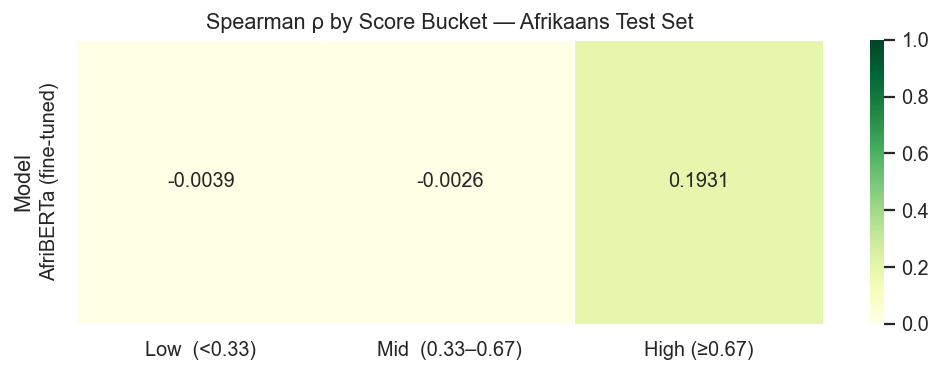

In [10]:
def spearman_by_bucket(preds, gold_scores, buckets):
    """Return Spearman rho for each bucket label."""
    bucket_results = {}
    for label, mask in buckets.items():
        if mask.sum() < 5:
            bucket_results[label] = np.nan
            continue
        bucket_results[label] = round(float(spearmanr(preds[mask], gold_scores[mask])[0]), 4)
    return bucket_results

buckets = {
    'Low  (<0.33)':   gold < 0.33,
    'Mid  (0.33–0.67)': (gold >= 0.33) & (gold < 0.67),
    'High (≥0.67)':   gold >= 0.67,
}

bucket_rows = []
for name, preds, _ in models_to_plot:
    row = {'Model': name}
    row.update(spearman_by_bucket(preds, gold, buckets))
    bucket_rows.append(row)

if bucket_rows:
    bucket_df = pd.DataFrame(bucket_rows).set_index('Model')
    print('Spearman ρ by score bucket:')
    display(bucket_df)

    # Heatmap
    fig, ax = plt.subplots(figsize=(8, max(3, len(bucket_rows) * 0.8 + 1)))
    sns.heatmap(bucket_df.astype(float), annot=True, fmt='.4f', cmap='YlGn',
                linewidths=0.5, ax=ax, vmin=0, vmax=1)
    ax.set_title('Spearman ρ by Score Bucket — Afrikaans Test Set')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'bucket_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()


## 10. Final Summary Table & Export

In [11]:
print('=' * 60)
print('FINAL RESULTS — Afrikaans SemRel2024 Test Set')
print('=' * 60)
display(results_df)

results_df.to_csv(os.path.join(OUTPUT_DIR, 'final_results.csv'))
print(f'\nResults saved to {OUTPUT_DIR}/final_results.csv')

# Best model
if not results_df.empty:
    best_model = results_df['Spearman'].idxmax()
    print(f'\nBest model by Spearman ρ: {best_model}  '
          f'(ρ = {results_df.loc[best_model, "Spearman"]:.4f})')


FINAL RESULTS — Afrikaans SemRel2024 Test Set


,Spearman,Pearson,MSE,RMSE
Model,,,,
AfriBERTa (fine-tuned),0.1527,0.1593,0.0534,0.2311



Results saved to ./evaluation_outputs/final_results.csv

Best model by Spearman ρ: AfriBERTa (fine-tuned)  (ρ = 0.1527)
